In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load processed data
train_df = pd.read_csv('../data/processed/train_df.csv')
test_df = pd.read_csv('../data/processed/test_df.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"\nTarget distribution in training set:")
print(train_df['label_repurchase'].value_counts(normalize=True))
print(f"\nColumn names:")
print(train_df.columns.tolist())

Train shape: (62509, 32)
Test shape: (15628, 32)

Target distribution in training set:
label_repurchase
1    0.562511
0    0.437489
Name: proportion, dtype: float64

Column names:
['user_id', 'session_id', 'session_event_count', 'event_type_nunique', 'session_main_events', 'session_browser', 'session_traffic_source', 'session_state', 'session_duration_hour', 'session_start_hour', 'session_start_weekday', 'session_start_is_weekend', 'session_start_day', 'session_start_week', 'session_start_month', 'session_start_quarter', 'session_start_year', 'session_end_hour', 'session_end_weekday', 'session_end_is_weekend', 'session_end_day', 'session_end_week', 'session_end_month', 'session_end_quarter', 'session_end_year', 'label_repurchase', 'product_seq_unique_str', 'product_category', 'total_price', 'user_age', 'user_gender', 'user_country']


In [3]:
# Prepare features and target
# Drop non-feature columns
drop_cols = ['user_id', 'session_id', 'label_repurchase']

# Separate features and target
X_train = train_df.drop(columns=drop_cols)
y_train = train_df['label_repurchase']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['label_repurchase']

# Handle categorical features - convert to numeric if needed
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

# One-hot encode categorical features
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align train and test columns
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(f"\nX_train shape: {X_train_encoded.shape}")
print(f"X_test shape: {X_test_encoded.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Categorical columns: ['session_main_events', 'session_browser', 'session_traffic_source', 'session_state', 'product_category', 'user_gender', 'user_country']

X_train shape: (62509, 301)
X_test shape: (15628, 301)
y_train shape: (62509,)
y_test shape: (15628,)


In [4]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("Features scaled successfully")

Features scaled successfully


In [5]:
from optuna.integration import OptunaSearchCV
import optuna
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Define objective function for Optuna
def objective(trial):
    # Suggest hyperparameters
    n_layers = trial.suggest_int('n_layers', 1, 6)
    hidden_sizes = []
    for i in range(n_layers):
        size = trial.suggest_categorical(f'layer_{i}_size', [16, 32, 64, 128, 256, 512])
        hidden_sizes.append(size)
    
    params = {
        'hidden_layer_sizes': tuple(hidden_sizes),
        'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-5, 1e-2, log=True),
        'batch_size': 4096,
        'activation': 'relu',
        'solver': 'adam',
        'learning_rate': 'adaptive',
        'max_iter': 300,
        'random_state': 42,
        'early_stopping': True,
        'validation_fraction': 0.2,
        'verbose': False
    }
    
    # Create and evaluate model
    mlp = MLPClassifier(**params)
    score = cross_val_score(mlp, X_train_scaled, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    
    return score

# Create Optuna study
print("Starting Optuna hyperparameter optimization...")
print("Optuna will automatically find the best parameters using Bayesian optimization\n")

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)

# Optimize
n_trials = 50
study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("\n" + "="*60)
print("OPTUNA OPTIMIZATION RESULTS")
print("="*60)
print(f"Number of finished trials: {len(study.trials)}")
print(f"Best trial ROC-AUC: {study.best_trial.value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

[I 2025-11-25 14:05:12,181] A new study created in memory with name: no-name-d62f807c-0eb9-4c68-a29e-77924ebe706c


Starting Optuna hyperparameter optimization...
Optuna will automatically find the best parameters using Bayesian optimization



  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-11-25 14:05:38,977] Trial 0 finished with value: 0.8017916354269364 and parameters: {'n_layers': 3, 'layer_0_size': 16, 'layer_1_size': 256, 'layer_2_size': 256, 'alpha': 0.0001461896279370495, 'learning_rate_init': 0.000684792009557478}. Best is trial 0 with value: 0.8017916354269364.


/Users/sung/purchase-conversion-prediction/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/sung/purchase-conversion-prediction/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/sung/purchase-conversion-prediction/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/sung/purchase-conversion-prediction/.venv/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reac

[I 2025-11-25 14:06:35,397] Trial 1 finished with value: 0.7989603692004777 and parameters: {'n_layers': 1, 'layer_0_size': 128, 'alpha': 0.00234238498471129, 'learning_rate_init': 1.3783237455007187e-05}. Best is trial 0 with value: 0.8017916354269364.
[I 2025-11-25 14:07:36,513] Trial 2 finished with value: 0.8028205735458642 and parameters: {'n_layers': 4, 'layer_0_size': 128, 'layer_1_size': 32, 'layer_2_size': 16, 'layer_3_size': 32, 'alpha': 0.04869640941520897, 'learning_rate_init': 1.8427970406864546e-05}. Best is trial 2 with value: 0.8028205735458642.
[I 2025-11-25 14:07:36,513] Trial 2 finished with value: 0.8028205735458642 and parameters: {'n_layers': 4, 'layer_0_size': 128, 'layer_1_size': 32, 'layer_2_size': 16, 'layer_3_size': 32, 'alpha': 0.04869640941520897, 'learning_rate_init': 1.8427970406864546e-05}. Best is trial 2 with value: 0.8028205735458642.
[I 2025-11-25 14:08:41,549] Trial 3 finished with value: 0.8088518860201233 and parameters: {'n_layers': 2, 'layer_0_s

In [6]:
# Reconstruct best hidden_layer_sizes
n_layers = study.best_trial.params['n_layers']
best_hidden_sizes = tuple([study.best_trial.params[f'layer_{i}_size'] for i in range(n_layers)])
print(f"\nBest hidden_layer_sizes: {best_hidden_sizes}")

# Train final model with best parameters
best_params = {
    'hidden_layer_sizes': best_hidden_sizes,
    'alpha': study.best_trial.params['alpha'],
    'learning_rate_init': study.best_trial.params['learning_rate_init'],
    'batch_size': 4096,
    'activation': 'relu',
    'solver': 'adam',
    'learning_rate': 'adaptive',
    'max_iter': 1000,
    'random_state': 42,
    'early_stopping': True,
    'validation_fraction': 0.2,
    'verbose': True
}

print("\n" + "="*60)
print("Training final model with best parameters...")
print("="*60)
mlp = MLPClassifier(**best_params)
mlp.fit(X_train_scaled, y_train)
print(f"\nTraining completed!")
print(f"Final training loss: {mlp.loss_:.4f}")
print(f"Number of iterations: {mlp.n_iter_}")


Best hidden_layer_sizes: (512,)

Training final model with best parameters...
Iteration 1, loss = 0.72882906
Validation score: 0.556151
Iteration 1, loss = 0.72882906
Validation score: 0.556151
Iteration 2, loss = 0.68338907
Validation score: 0.601904
Iteration 2, loss = 0.68338907
Validation score: 0.601904
Iteration 3, loss = 0.64969050
Validation score: 0.632859
Iteration 3, loss = 0.64969050
Validation score: 0.632859
Iteration 4, loss = 0.62360003
Validation score: 0.657895
Iteration 4, loss = 0.62360003
Validation score: 0.657895
Iteration 5, loss = 0.60302898
Validation score: 0.673972
Iteration 5, loss = 0.60302898
Validation score: 0.673972
Iteration 6, loss = 0.58653880
Validation score: 0.683491
Iteration 6, loss = 0.58653880
Validation score: 0.683491
Iteration 7, loss = 0.57277259
Validation score: 0.692929
Iteration 7, loss = 0.57277259
Validation score: 0.692929
Iteration 8, loss = 0.56110810
Validation score: 0.696849
Iteration 8, loss = 0.56110810
Validation score: 0.

In [7]:
# Visualize Optuna optimization results
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_parallel_coordinate

# Optimization history
fig1 = plot_optimization_history(study)
fig1.update_layout(title="Optimization History", width=800, height=500)
fig1.show()

# Parameter importances
fig2 = plot_param_importances(study)
fig2.update_layout(title="Hyperparameter Importances", width=800, height=500)
fig2.show()

# Parallel coordinate plot
fig3 = plot_parallel_coordinate(study, params=['alpha', 'learning_rate_init'])
fig3.update_layout(title="Parallel Coordinate Plot", width=1000, height=600)
fig3.show()

# Create summary DataFrame
trials_df = study.trials_dataframe()
print("\nTop 10 Trials:")
print(trials_df.nlargest(10, 'value')[['number', 'value', 'params_alpha', 'params_learning_rate_init', 'params_n_layers']])


Top 10 Trials:
    number     value  params_alpha  params_learning_rate_init  params_n_layers
28      28  0.811962      0.000018                   0.000094                1
41      41  0.811809      0.000010                   0.000321                1
29      29  0.811782      0.000017                   0.000138                1
40      40  0.811379      0.000020                   0.000403                1
42      42  0.811311      0.000021                   0.000416                1
43      43  0.810978      0.000025                   0.000444                1
32      32  0.810962      0.000063                   0.000070                1
33      33  0.810784      0.000011                   0.000110                1
38      38  0.810568      0.000088                   0.000172                1
22      22  0.810547      0.007983                   0.000030                2


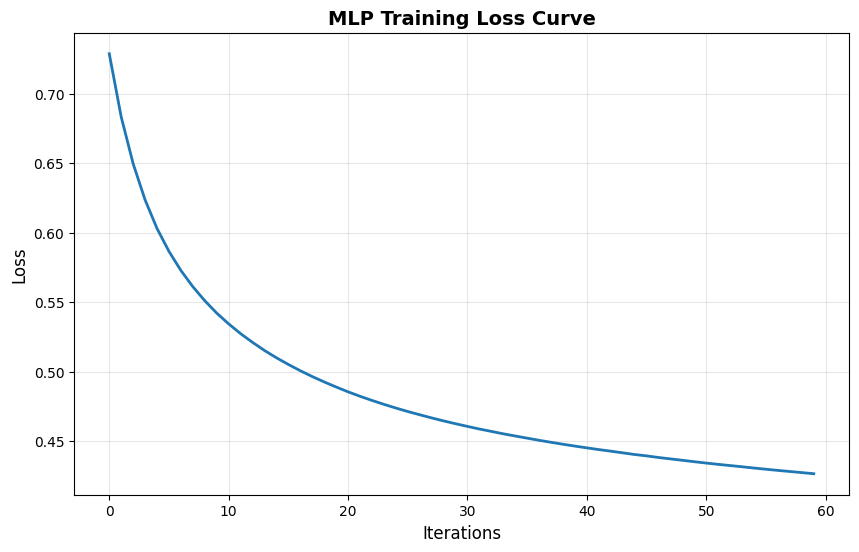

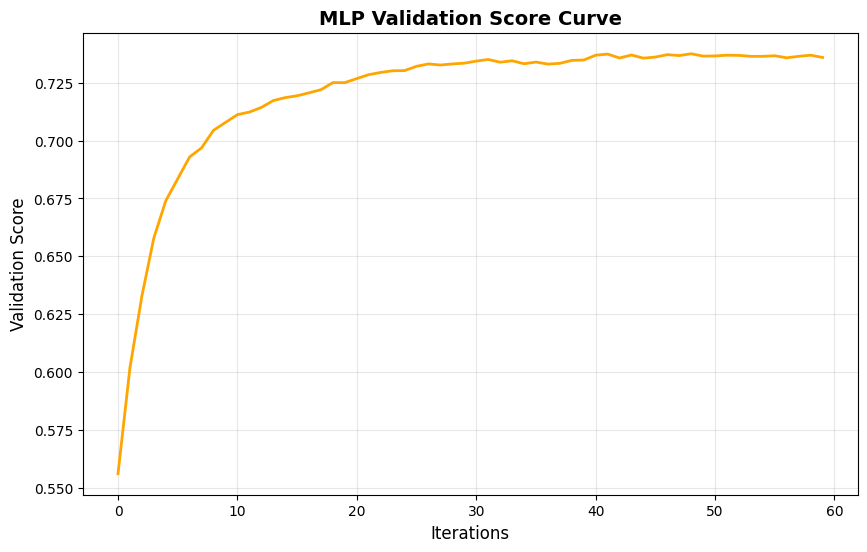

In [8]:
# Plot training loss curve
plt.figure(figsize=(10, 6))
plt.plot(mlp.loss_curve_, linewidth=2)
plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('MLP Training Loss Curve', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

# Plot validation scores if available
if hasattr(mlp, 'validation_scores_'):
    plt.figure(figsize=(10, 6))
    plt.plot(mlp.validation_scores_, linewidth=2, color='orange')
    plt.xlabel('Iterations', fontsize=12)
    plt.ylabel('Validation Score', fontsize=12)
    plt.title('MLP Validation Score Curve', fontsize=14, fontweight='bold')
    plt.grid(alpha=0.3)
    plt.show()

In [9]:
# Make predictions
y_train_pred = mlp.predict(X_train_scaled)
y_test_pred = mlp.predict(X_test_scaled)

y_train_pred_proba = mlp.predict_proba(X_train_scaled)[:, 1]
y_test_pred_proba = mlp.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully")

Predictions generated successfully


In [10]:
# Save the model and scaler
import joblib

model_path = '../data/models/mlp_model.pkl'
scaler_path = '../data/models/scaler.pkl'

joblib.dump(mlp, model_path)
joblib.dump(scaler, scaler_path)

print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")

Model saved to: ../data/models/mlp_model.pkl
Scaler saved to: ../data/models/scaler.pkl


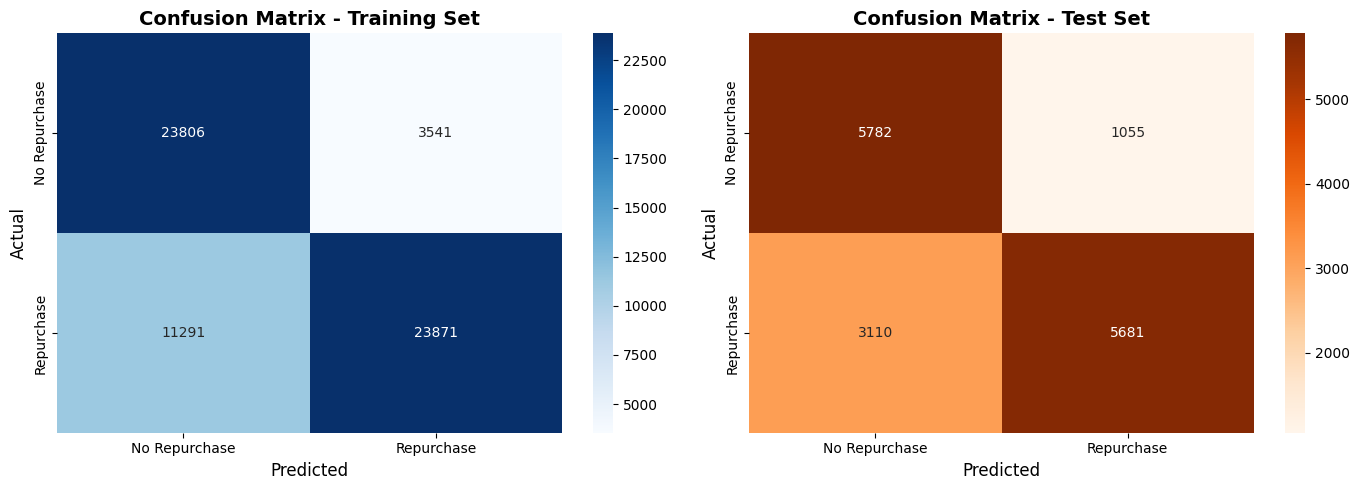

In [11]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training confusion matrix
cm_train = confusion_matrix(y_train, y_train_pred)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=True)
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title('Confusion Matrix - Training Set', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['No Repurchase', 'Repurchase'])
axes[0].set_yticklabels(['No Repurchase', 'Repurchase'])

# Test confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=True)
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['No Repurchase', 'Repurchase'])
axes[1].set_yticklabels(['No Repurchase', 'Repurchase'])

plt.tight_layout()
plt.show()

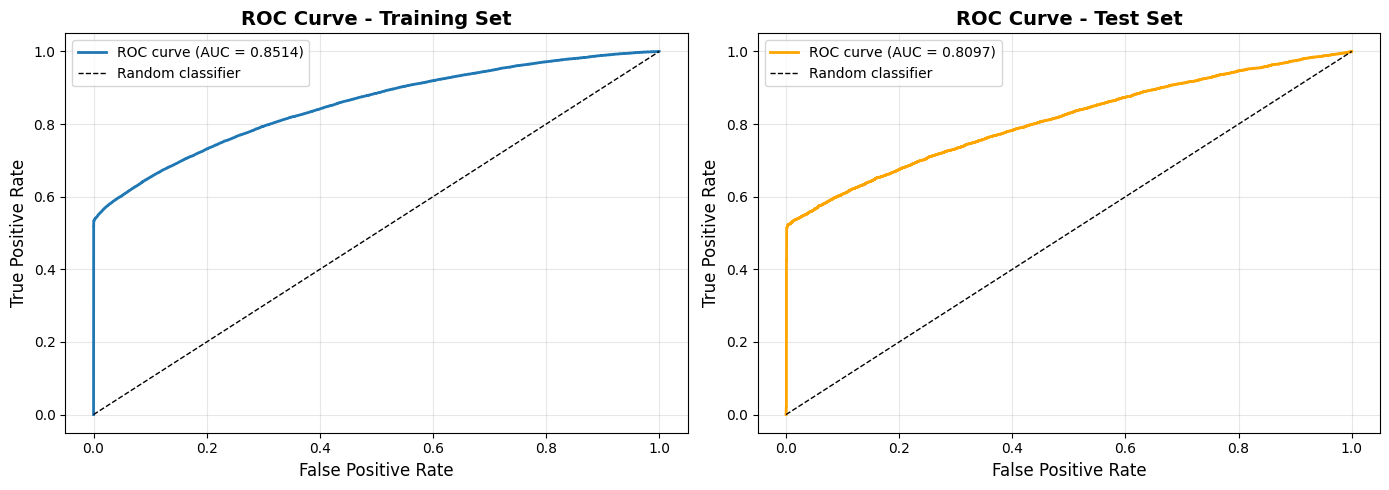

In [12]:
# Plot ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training ROC curve
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_proba)
axes[0].plot(fpr_train, tpr_train, label=f'ROC curve (AUC = {roc_auc_score(y_train, y_train_pred_proba):.4f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random classifier', linewidth=1)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve - Training Set', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Test ROC curve
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_proba)
axes[1].plot(fpr_test, tpr_test, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_test_pred_proba):.4f})', linewidth=2, color='orange')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random classifier', linewidth=1)
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve - Test Set', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Evaluate model performance
print("=" * 60)
print("TRAINING SET PERFORMANCE")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_train, y_train_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_train, y_train_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))

print("\n" + "=" * 60)
print("TEST SET PERFORMANCE")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

TRAINING SET PERFORMANCE
Accuracy: 0.7627
ROC-AUC: 0.8514

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.87      0.76     27347
           1       0.87      0.68      0.76     35162

    accuracy                           0.76     62509
   macro avg       0.77      0.77      0.76     62509
weighted avg       0.79      0.76      0.76     62509


Confusion Matrix:
[[23806  3541]
 [11291 23871]]

TEST SET PERFORMANCE
Accuracy: 0.7335
ROC-AUC: 0.8097

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.85      0.74      6837
           1       0.84      0.65      0.73      8791

    accuracy                           0.73     15628
   macro avg       0.75      0.75      0.73     15628
weighted avg       0.76      0.73      0.73     15628


Confusion Matrix:
[[5782 1055]
 [3110 5681]]
